In [1]:
# Somtimes we need to Generate the PDF Reprots
# In this notebook we will create a pdf.
# Our objective is to create a simple PDF with a matplotlib.
# We will use Reportlab and Pandas for this pdf Generation


In [29]:
# First we will do the necessary Imports
import pandas as pd
import matplotlib.pyplot as plt
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4

# we will use matploltib chart as imange in our pdf
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Image , Paragraph
from reportlab.lib.utils import ImageReader 

In [3]:
# First we will read the necessary data


In [4]:
import os
os.getcwd()

'c:\\Users\\Seder\\Documents\\GitHub\\Data-Analysis\\Reports(MS-Excel&Word)'

In [5]:
# We use the same data which was generated with with our Data_Generation notebook

# Now we have employees and managers with.
employees = pd.read_excel('Data/EmployeesDetails.xlsx', usecols=['EmpID', 'DisplayName', 'ManagerID'])
managers = pd.read_excel('Data/Managers.xlsx')

# We need to know that employees percentages work under one manager. 
# Top 5 we will create a pie chart and send it to our pdf.
# Where as remaining we will send in our pdf file as table.

df = employees.merge(managers,left_on='ManagerID', right_on='EmpID').value_counts(['DisplayName_y']).reset_index()


In [6]:
# df = df.columns.tolist(), df.values.tolist()



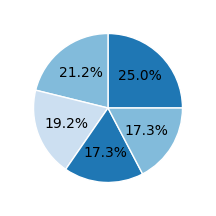

In [16]:
# Now we will Create a pie chart

fig, ax = plt.subplots(figsize=(4,2))
plt.style.use('_mpl-gallery-nogrid')

# (np.linspace(0.2, 0.7, len(x)))


ax.pie(df[:5]['count'].tolist(), radius=.95,  autopct='%1.1f%%', wedgeprops={"linewidth": 1, "edgecolor": "white"})

# We had created a Pie chart and save under the name of My-Pie.PNG

plt.savefig('Data/Matplotlib/My-Pie.PNG'    )


In [ ]:
# Now we will create our PDF Report
# Create a Doucment
doc = SimpleDocTemplate('Data/Matplotlib/PdfReport.pdf', pagesize=A4)

# Read Pnadas Dataframe as Reportlab Table
table = Table(pd.DataFrame(df).reset_index().values.tolist())

# Add some formatting and style to our table
head = Paragraph('Funtos PDF Reporting System')

# Styles can be set on any object, but i had demo at table only

table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.lightblue),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)
]))

# Insert image
img = Image('Data/Matplotlib/Project - 1.PNG', width=400, height=200)
img2 = Image('Data/Matplotlib/My-Pie.PNG', width=300, height=200)  # Adjust width and height as needed

sideHead = Paragraph('Top 5 Managers')

detail = Paragraph('All the employees are reported to differenct managers')

elements = [head, img, sideHead,detail , img2, table]  # Add image to elements list
doc.build(elements)


In [14]:
pd.DataFrame(df).reset_index().values.tolist()

[[0, 'Alexander Garcia', 13],
 [1, 'Nicole Williams', 11],
 [2, 'Jason Bryant', 10],
 [3, 'Tommy Weeks', 9],
 [4, 'Victoria Nelson', 9],
 [5, 'Matthew Johnston', 8],
 [6, 'Sherry Phillips', 8],
 [7, 'Erica Mason', 7],
 [8, 'Megan Dixon', 6],
 [9, 'Nicholas Chan', 6],
 [10, 'Barbara Gomez', 5],
 [11, 'Katherine Whitney', 5]]